# Load Data

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns

# File name
RAW_DATA_FILE_NAME = "loan_data.csv"

PROJECT_ROOT = Path("..")
RAW_DATA_FILE_PATH = PROJECT_ROOT / "data" / "raw" / RAW_DATA_FILE_NAME

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Raw data path:", RAW_DATA_FILE_PATH)

df = pd.read_csv(RAW_DATA_FILE_PATH)
print(df.shape)
df.head()

PROJECT_ROOT: ..
Raw data path: ..\data\raw\loan_data.csv
(45000, 14)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


# Plot Categorical Data

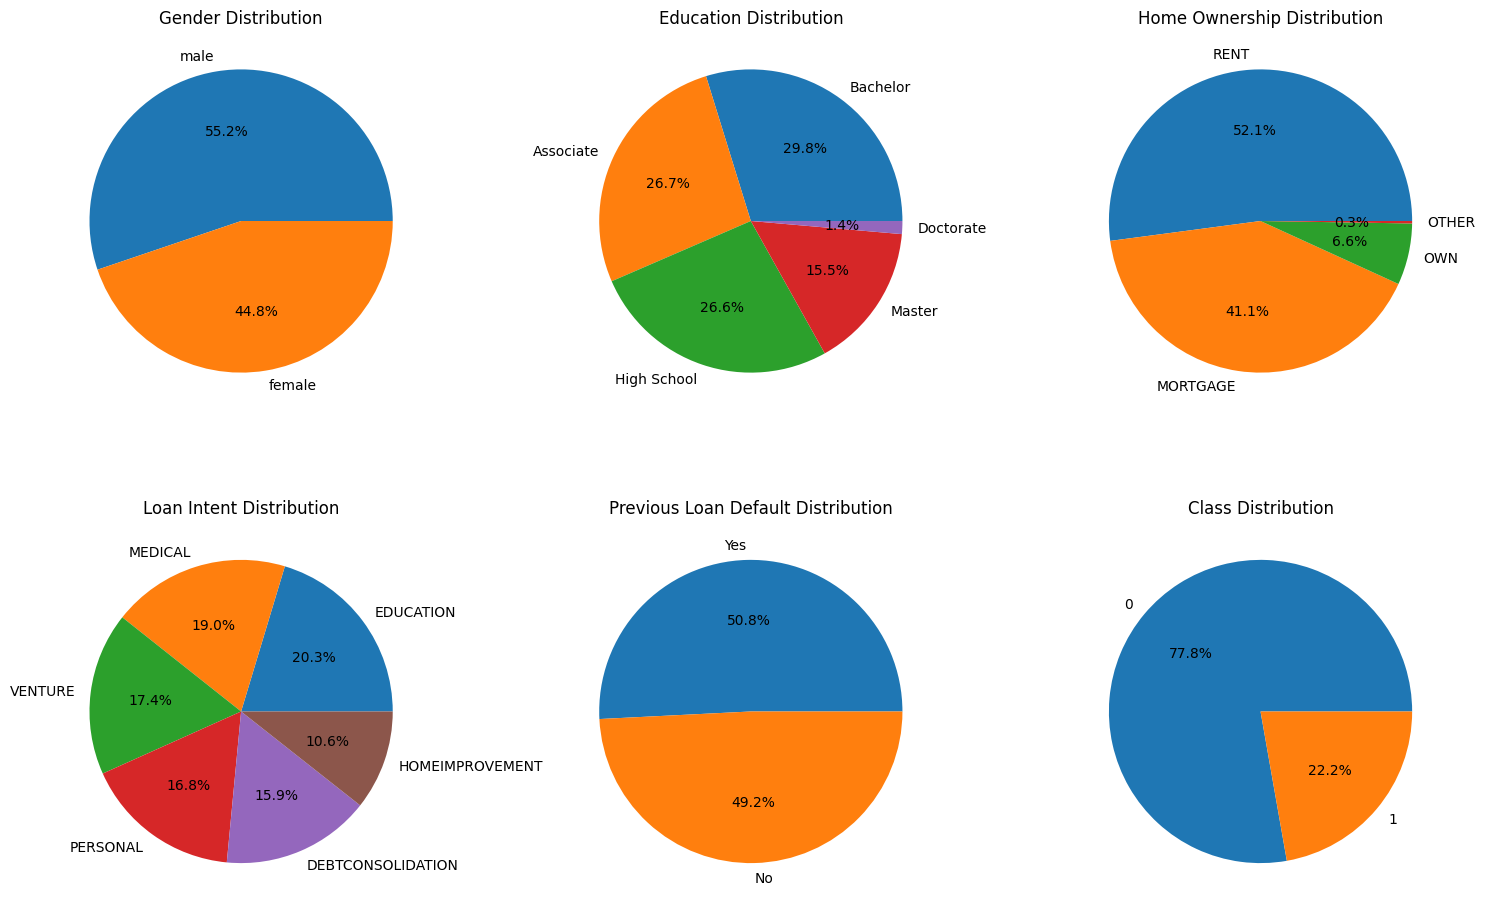

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes = axes.flatten()

categorical_col = ['person_gender',
                   'person_education',
                   'person_home_ownership',
                   'loan_intent',
                   'previous_loan_defaults_on_file',
                   'loan_status'
                  ]

titles = ['Gender Distribution',
          'Education Distribution',
          'Home Ownership Distribution',
          'Loan Intent Distribution',
          'Previous Loan Default Distribution',
          'Class Distribution'
         ]

for i, col in enumerate(categorical_col):
    counts = df[col].value_counts()
    axes[i].pie(counts, labels=counts.index, autopct='%1.1f%%')
    axes[i].set_title(titles[i])

plt.tight_layout()
plt.show()

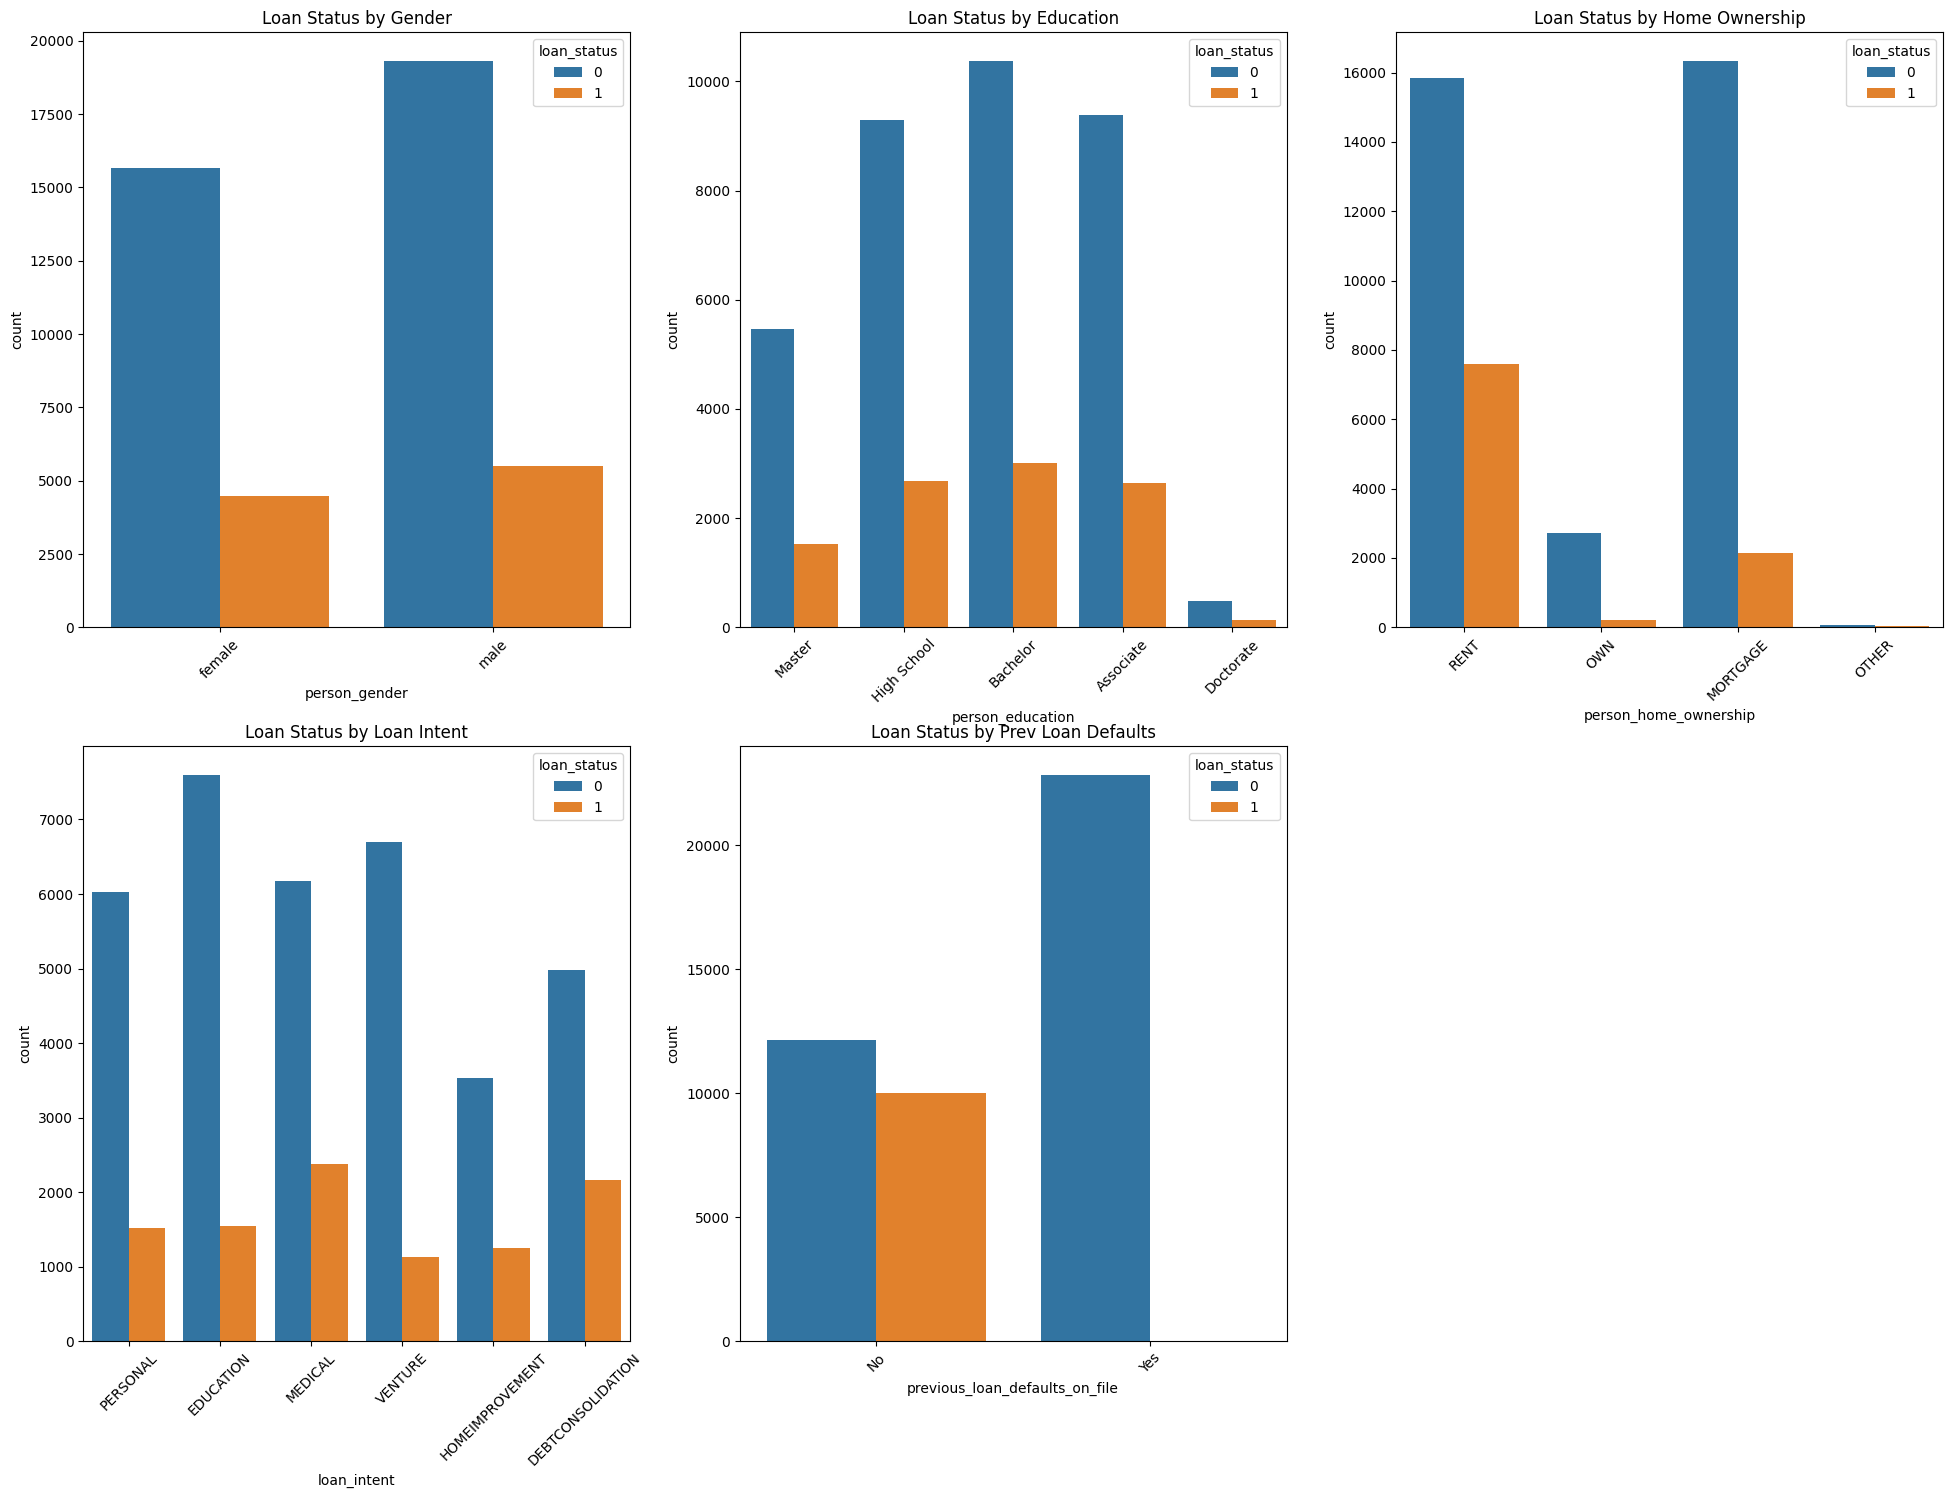

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(24, 17))

axes = axes.flatten()

categorical_col = ['person_gender',
                   'person_education',
                   'person_home_ownership',
                   'loan_intent',
                   'previous_loan_defaults_on_file'
                  ]
titles = ['Loan Status by Gender',
          'Loan Status by Education',
          'Loan Status by Home Ownership',
          'Loan Status by Loan Intent',
          'Loan Status by Prev Loan Defaults'
         ]

for i in range(len(categorical_col)):
    sns.countplot(data=df, x=categorical_col[i], hue='loan_status', ax=axes[i])
    axes[i].set_title(titles[i])
    axes[i].tick_params(axis='x', rotation=45)
    
axes[-1].set_visible(False)
plt.show()

# Plot Numerical Data

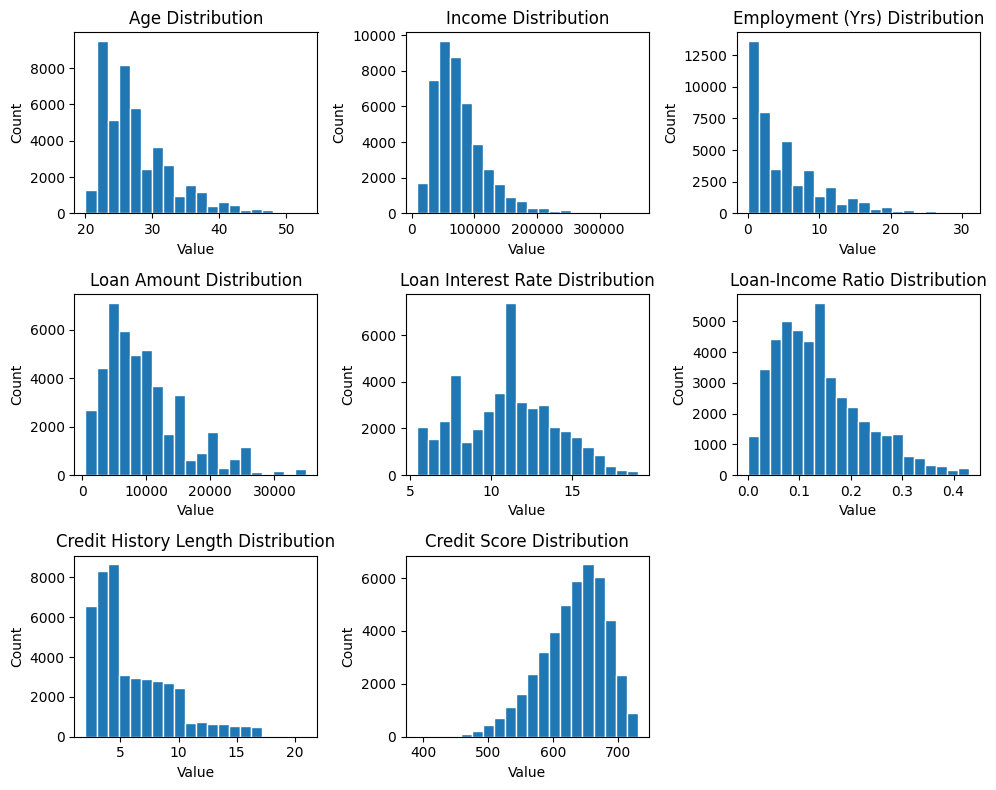

In [4]:
num_cols = ['person_age',
            'person_income',
            'person_emp_exp',
            'loan_amnt',
            'loan_int_rate',
            'loan_percent_income',
            'cb_person_cred_hist_length',
            'credit_score'
           ]

num_df = df[num_cols]

fig, axes = plt.subplots(3, 3, figsize=(10, 8))

axes = axes.flatten()

titles = ["Age Distribution",
          "Income Distribution",
          "Employment (Yrs) Distribution",
          "Loan Amount Distribution",
          "Loan Interest Rate Distribution",
          "Loan-Income Ratio Distribution",
          "Credit History Length Distribution",
          "Credit Score Distribution"]

for i, col in enumerate(num_cols):
    # Since there are many outliers in the dataset that skew the plot heavily, we plot the left 99.5% of the data instead.
    quantile_99 = num_df[col].quantile(0.995)
    axes[i].hist(num_df[col][num_df[col] <= quantile_99], bins=20, edgecolor="white")
    axes[i].set_title(titles[i])
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

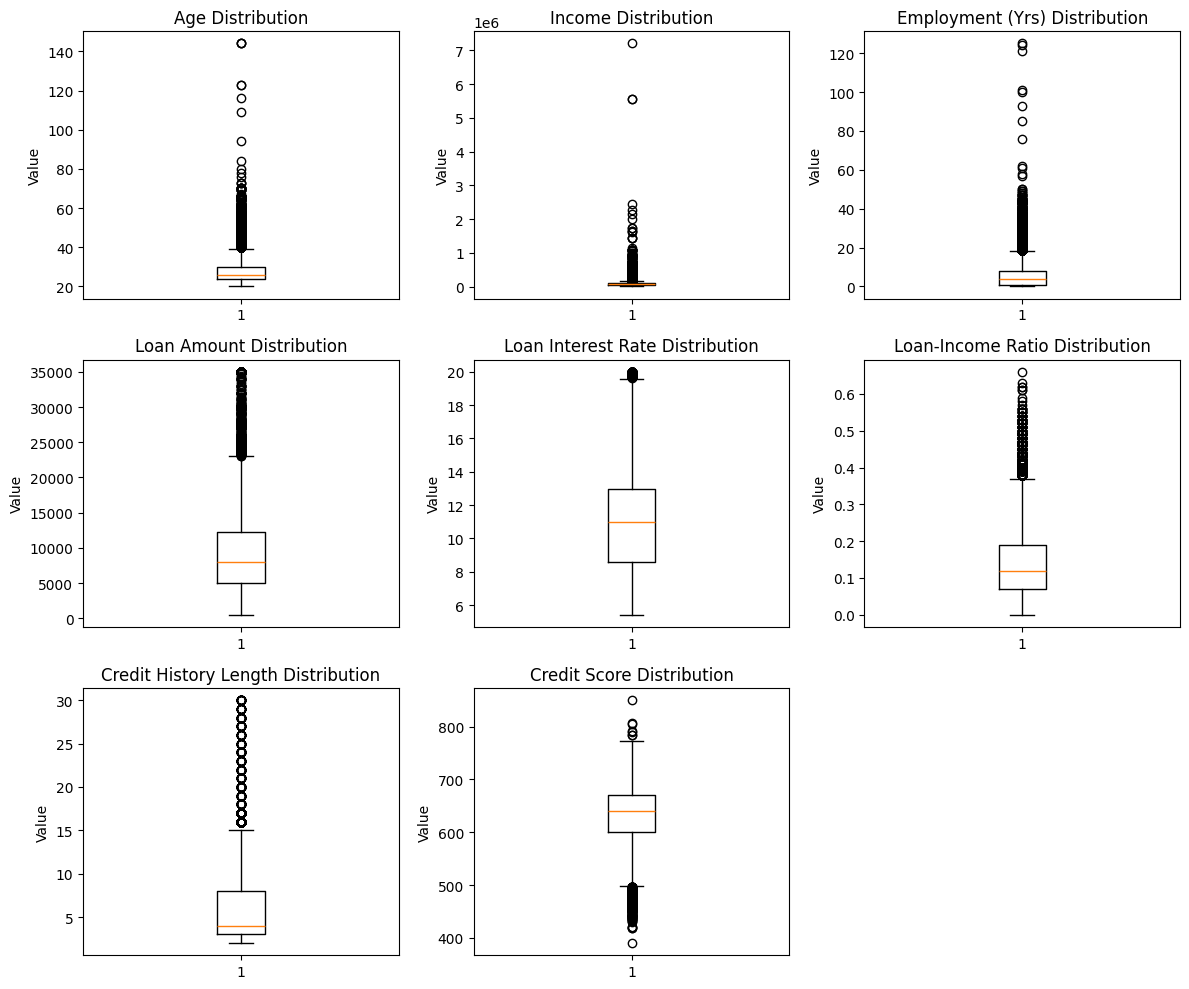

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(num_df):
    axes[i].boxplot(num_df[col].dropna())
    axes[i].set_title(titles[i])
    axes[i].set_ylabel("Value")

# hide the empty 9th subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

# Correlation Analysis

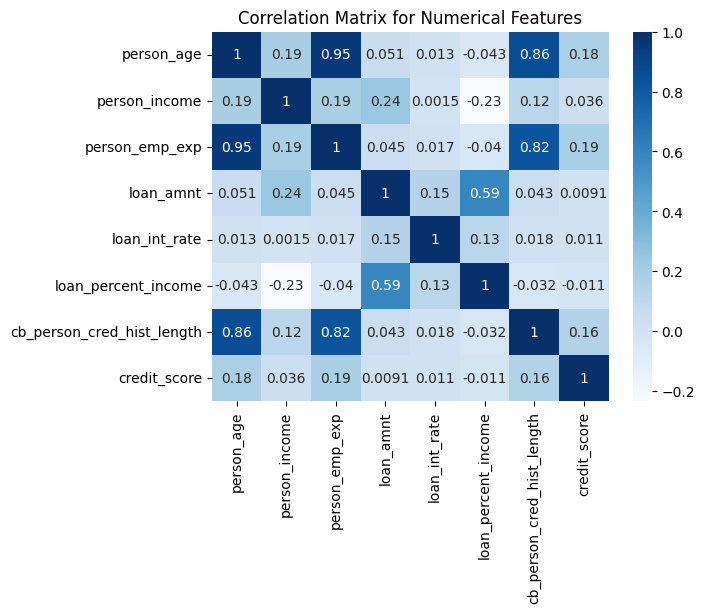

In [8]:
corr_matrix = num_df.corr()

ax = sns.heatmap(corr_matrix, annot=True, cmap='Blues')

ax.set_title('Correlation Matrix for Numerical Features')

plt.show()


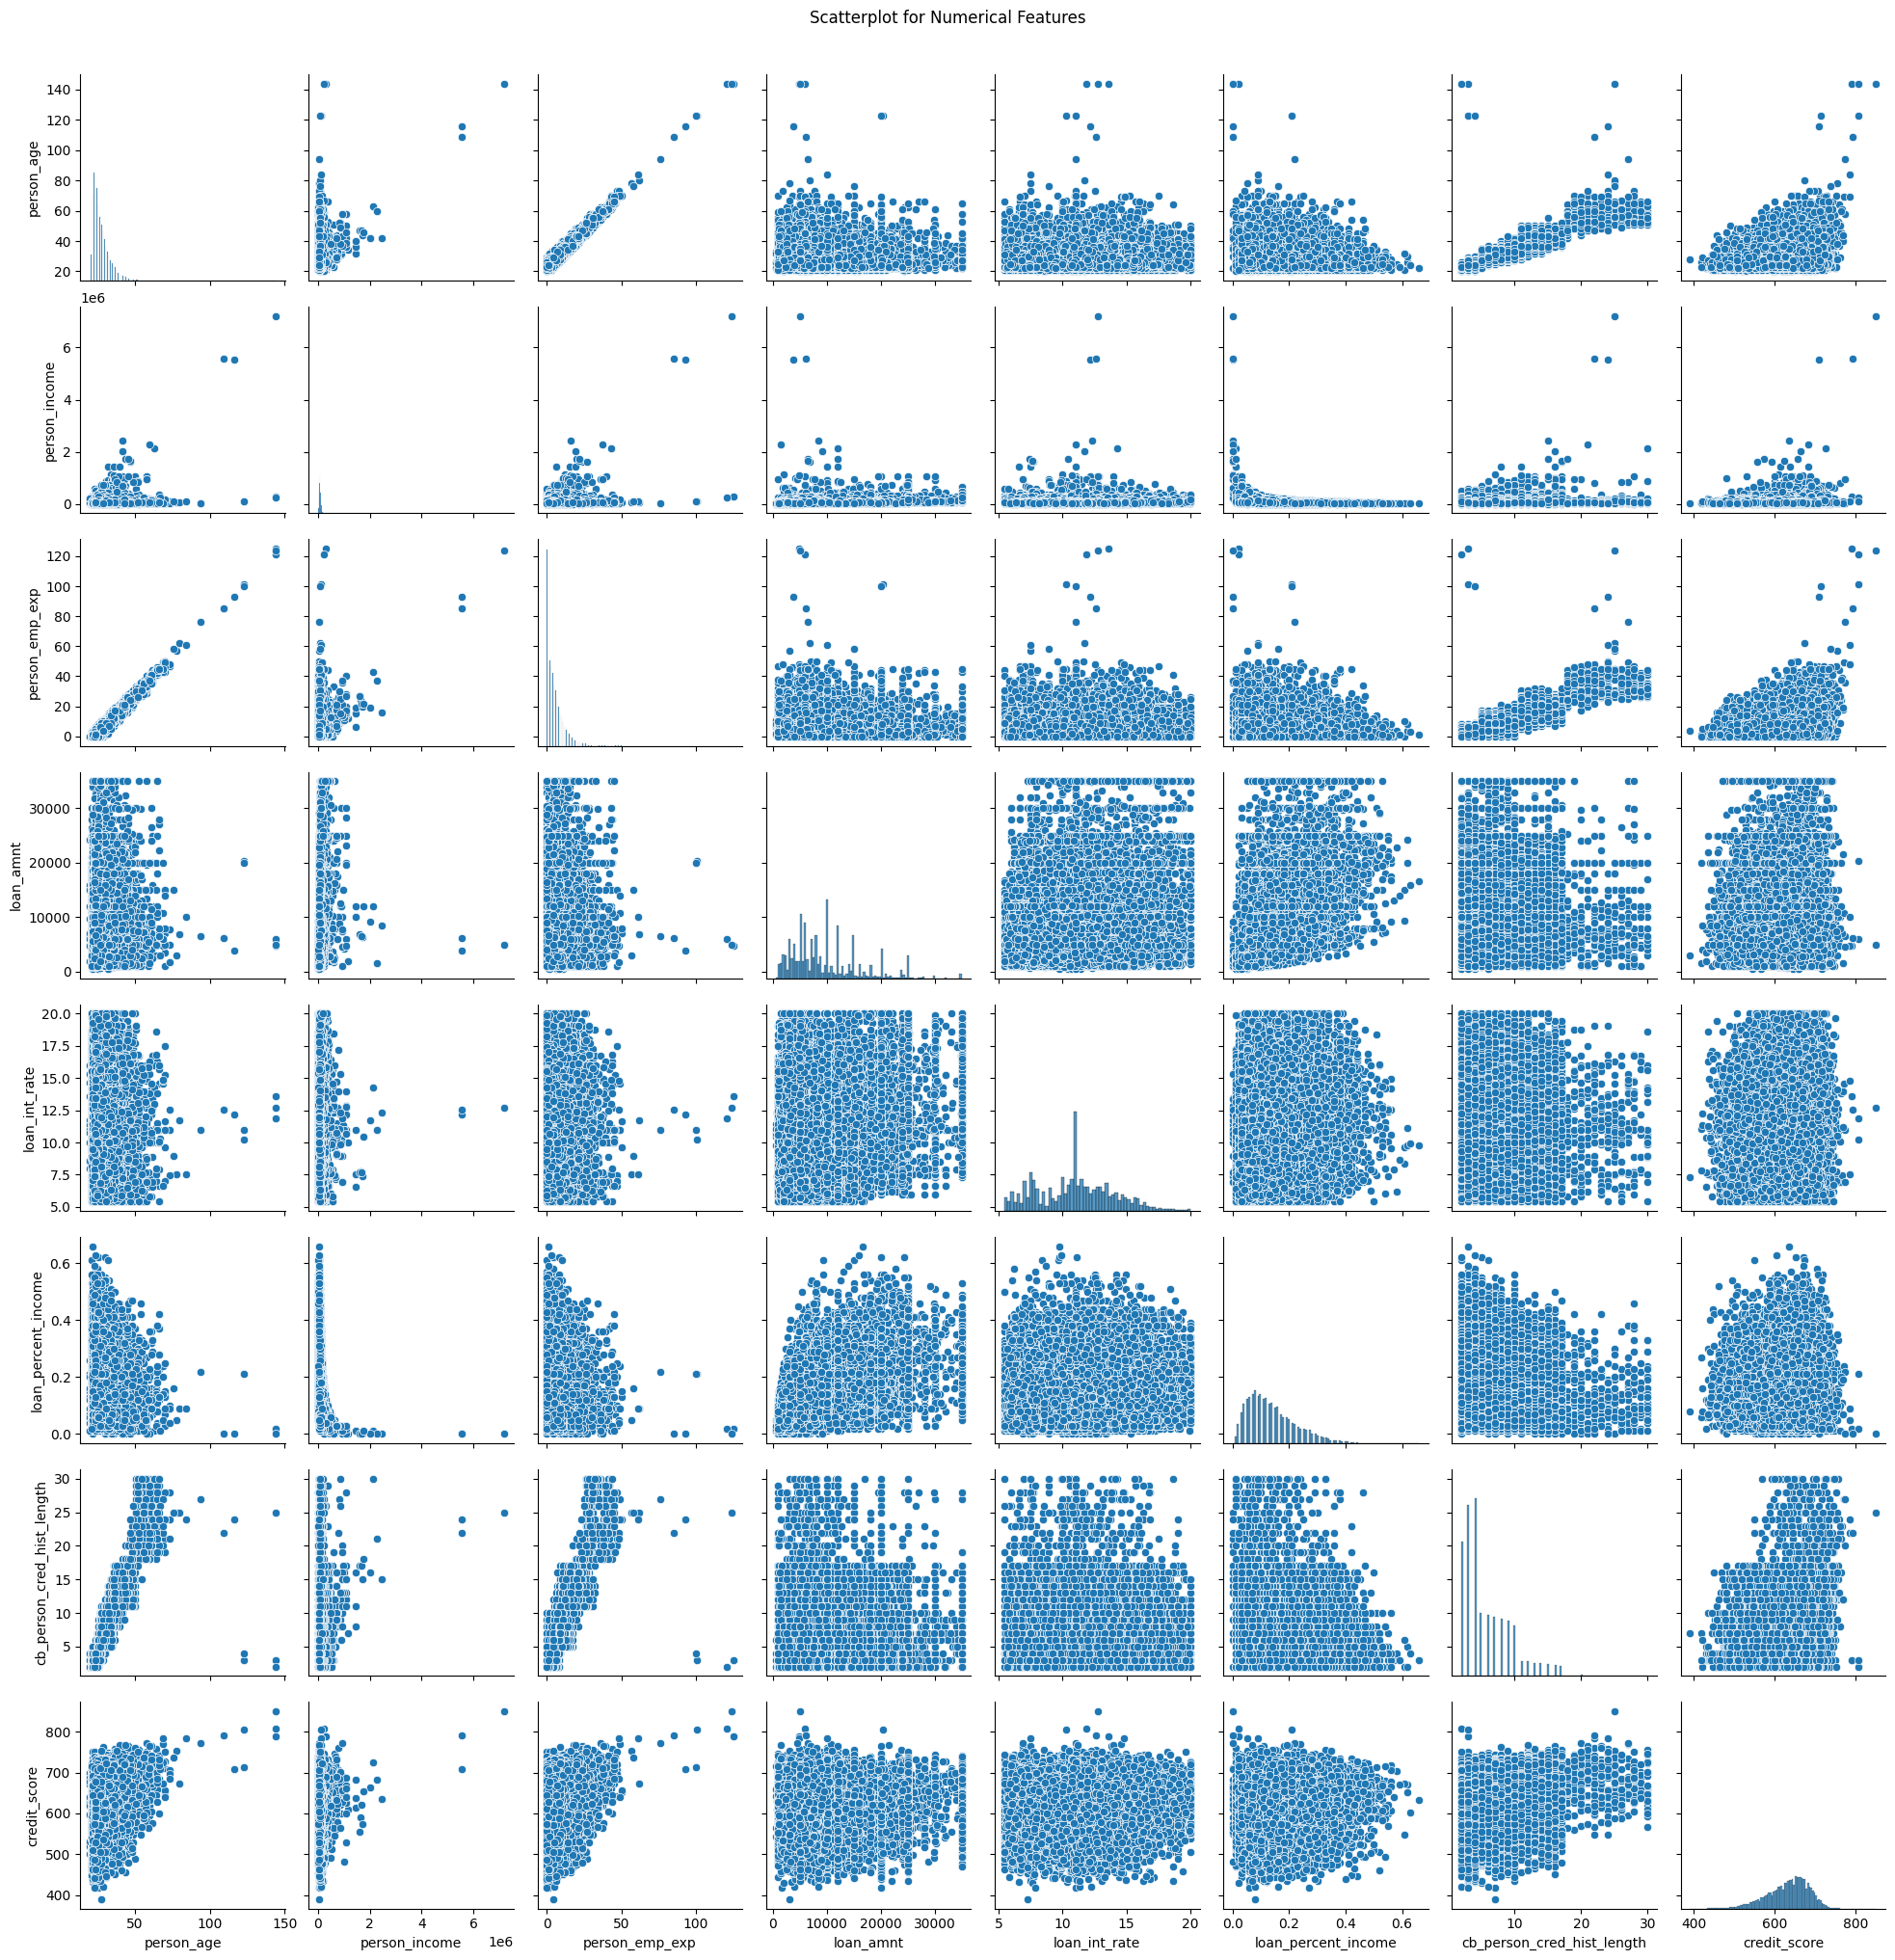

In [9]:
ax = sns.pairplot(num_df)
ax.fig.suptitle('Scatterplot for Numerical Features', y=1.02)
plt.show()

In [11]:
df.groupby('loan_status')[num_cols].agg(['min', 'max', 'mean', 'median', 'std']).round(2).stack(future_stack=True)

person_age  person_income  person_emp_exp  loan_amnt  \
loan_status                                                                
0           min          20.00        9595.00            0.00     500.00   
            max         144.00     7200766.00          125.00   35000.00   
            mean         27.83       86157.04            5.48    9219.58   
            median       26.00       72928.00            4.00    8000.00   
            std           6.07       87035.24            6.10    6018.93   
1           min          20.00        8000.00            0.00     900.00   
            max          70.00      845636.00           47.00   35000.00   
            mean         27.52       59886.10            5.18   10855.69   
            median       26.00       50629.00            3.00    9750.00   
            std           5.94       45338.32            5.91    7111.70   

                    loan_int_rate  loan_percent_income  \
loan_status                                              
0           min              5.42                 0.00   
            max             20.00                 0.66   
            mean            10.48                 0.12   
            median          10.85                 0.11   
            std              2.73                 0.07   
1           min              5.42                 0.00   
            max             20.00                 0.62   
            mean            12.86                 0.20   
            median          12.98                 0.20   
            std              3.07                 0.11   

                    cb_person_cred_hist_length  credit_score  
loan_status                                                   
0           min                           2.00        390.00  
            max                          30.00        850.00  
            mean                          5.90        632.81  
            median                        4.00        640.00  
            std                           3.87         50.48  
1           min                           2.00        431.00  
            max                          30.00        767.00  
            mean                          5.76        631.89  
            median                        4.00        639.00  
            std                           3.90         50.29